**Build an RNN based model (LSTM, GRU)**

In [ ]:
from math import sqrt
from numpy import concatenate
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from datetime import datetime
from matplotlib import pyplot
import matplotlib.pyplot as plt

**improved code**

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 - 4s - 555ms/step - loss: 0.1174 - val_loss: 0.4795
Epoch 2/50
8/8 - 0s - 18ms/step - loss: 0.0823 - val_loss: 0.3055
Epoch 3/50
8/8 - 0s - 31ms/step - loss: 0.0731 - val_loss: 0.1928
Epoch 4/50
8/8 - 0s - 32ms/step - loss: 0.0680 - val_loss: 0.1633
Epoch 5/50
8/8 - 0s - 31ms/step - loss: 0.0433 - val_loss: 0.1122
Epoch 6/50
8/8 - 0s - 30ms/step - loss: 0.0313 - val_loss: 0.1390
Epoch 7/50
8/8 - 0s - 29ms/step - loss: 0.0264 - val_loss: 0.0989
Epoch 8/50
8/8 - 0s - 30ms/step - loss: 0.0305 - val_loss: 0.1165
Epoch 9/50
8/8 - 0s - 31ms/step - loss: 0.0345 - val_loss: 0.1154
Epoch 10/50
8/8 - 0s - 38ms/step - loss: 0.0404 - val_loss: 0.1068
Epoch 11/50
8/8 - 0s - 31ms/step - loss: 0.0272 - val_loss: 0.0936
Epoch 12/50
8/8 - 0s - 27ms/step - loss: 0.0282 - val_loss: 0.1133
Epoch 13/50
8/8 - 0s - 19ms/step - loss: 0.0240 - val_loss: 0.1205
Epoch 14/50
8/8 - 0s - 19ms/step - loss: 0.0331 - val_loss: 0.1208
Epoch 15/50
8/8 - 0s - 18ms/step - loss: 0.0286 - val_loss: 0.0934
Epoch 16/50
8/

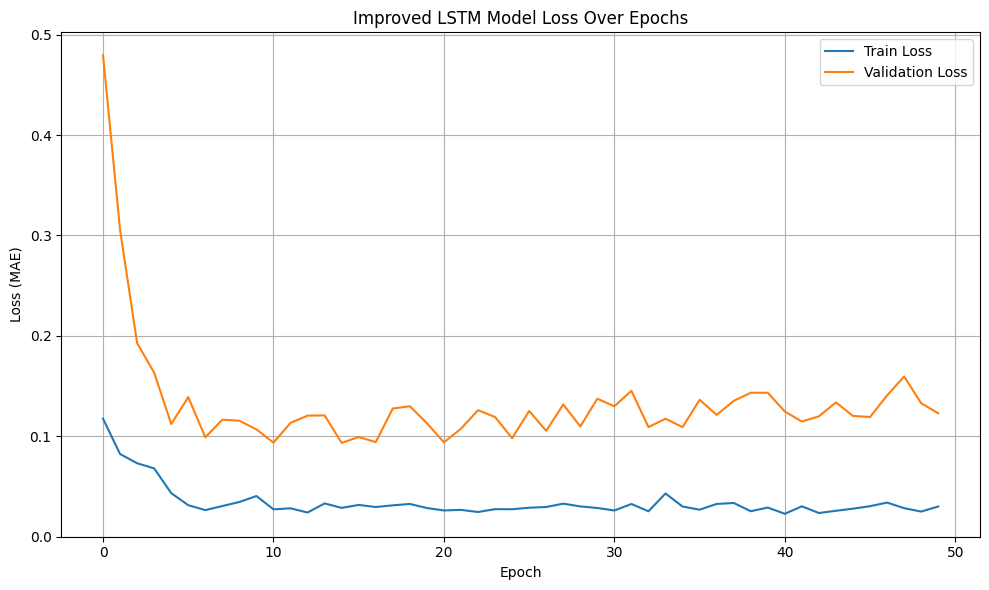

<ipython-input-26-b908c7393baa>:98: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=24, freq='Q')


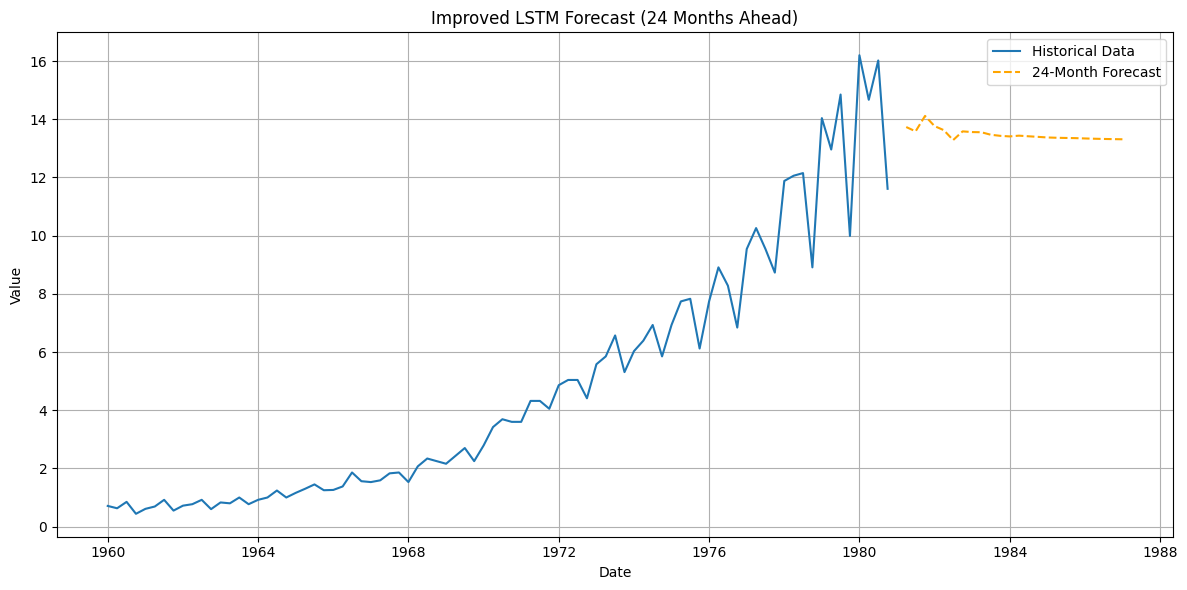

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
Model Performance:
Mean Absolute Error (MAE):      1.9362
Mean Squared Error (MSE):       4.4417
Root Mean Squared Error (RMSE): 2.1075
R-squared (R² Score):           0.2409


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame, concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Load dataset
df = pd.read_csv('/content/jj.csv')
df.columns = ['date', 'data']
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Normalize the 'data' column
values = df[['data']].values.astype('float32')
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# Convert to supervised learning format
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df = DataFrame(data)
    cols, names = [], []
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        names += [f'var{j+1}(t+{i})' for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

# Use 6 time steps
df_supervised = series_to_supervised(scaled, n_in=6, n_out=1)

# Split into X and y
X = df_supervised.iloc[:, :-1]
y = df_supervised.iloc[:, -1]

# Train/test split (no shuffle to preserve sequence)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Reshape input for LSTM [samples, timesteps, features]
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

# Define improved LSTM model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=2,
    shuffle=False
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Improved LSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Forecast 24 quarters ahead
last_sequence = scaled[-6:]
forecast = []
for _ in range(24):
    input_seq = last_sequence.reshape((1, 6, 1))
    next_val = model.predict(input_seq, verbose=0)
    forecast.append(next_val[0, 0])
    last_sequence = np.append(last_sequence[1:], [[next_val[0, 0]]], axis=0)

# Inverse scale forecast
forecast_inv = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# Forecast index
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=24, freq='Q')
forecast_df = pd.DataFrame(forecast_inv, index=forecast_index, columns=['Forecast'])

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='24-Month Forecast', color='orange', linestyle='--')
plt.title('Improved LSTM Forecast (24 Months Ahead)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ------------------------------
# Evaluate performance on test set
# ------------------------------
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.values.reshape(-1, 1))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print("Model Performance:")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):           {r2:.4f}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 - 5s - 668ms/step - loss: 0.0466 - val_loss: 0.0991
Epoch 2/50
8/8 - 1s - 89ms/step - loss: 0.0846 - val_loss: 0.1223
Epoch 3/50
8/8 - 0s - 20ms/step - loss: 0.0518 - val_loss: 0.1342
Epoch 4/50
8/8 - 0s - 20ms/step - loss: 0.0274 - val_loss: 0.1078
Epoch 5/50
8/8 - 0s - 21ms/step - loss: 0.0346 - val_loss: 0.1577
Epoch 6/50
8/8 - 0s - 35ms/step - loss: 0.0300 - val_loss: 0.1863
Epoch 7/50
8/8 - 0s - 19ms/step - loss: 0.0328 - val_loss: 0.1334
Epoch 8/50
8/8 - 0s - 37ms/step - loss: 0.0331 - val_loss: 0.1489
Epoch 9/50
8/8 - 0s - 19ms/step - loss: 0.0368 - val_loss: 0.1108
Epoch 10/50
8/8 - 0s - 22ms/step - loss: 0.0376 - val_loss: 0.1052
Epoch 11/50
8/8 - 0s - 37ms/step - loss: 0.0383 - val_loss: 0.0961
Epoch 12/50
8/8 - 0s - 37ms/step - loss: 0.0294 - val_loss: 0.1032
Epoch 13/50
8/8 - 0s - 37ms/step - loss: 0.0367 - val_loss: 0.1503
Epoch 14/50
8/8 - 0s - 22ms/step - loss: 0.0262 - val_loss: 0.1106
Epoch 15/50
8/8 - 0s - 20ms/step - loss: 0.0327 - val_loss: 0.1909
Epoch 16/50
8/

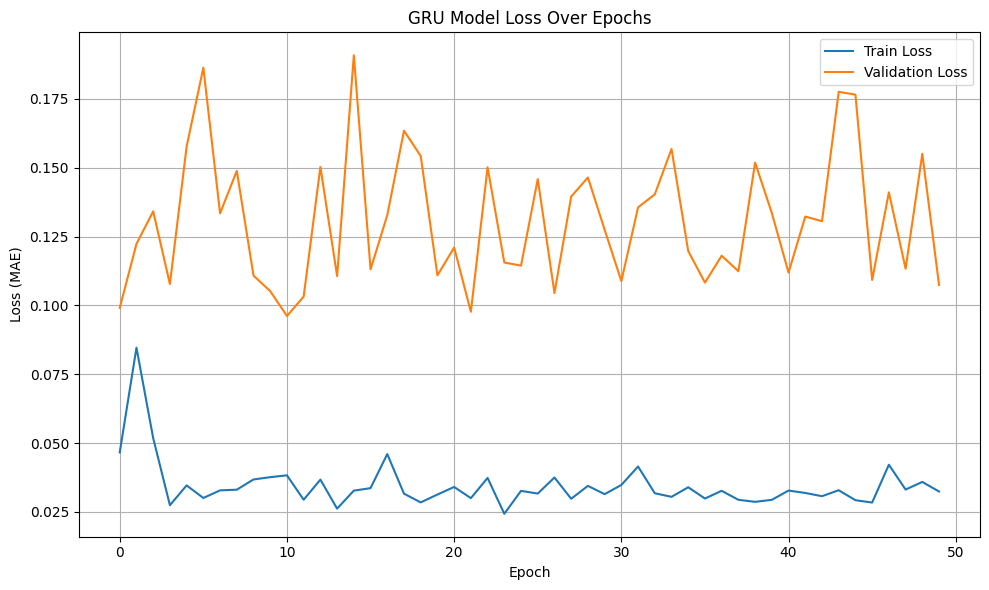

<ipython-input-28-542329e17f2b>:50: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=24, freq='Q')


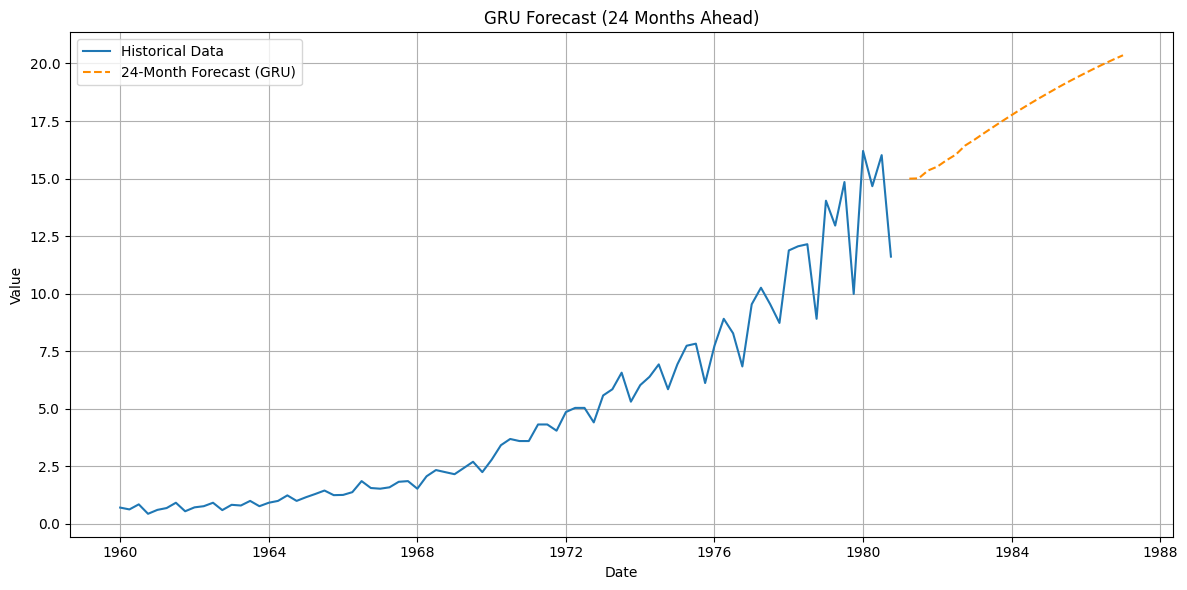

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
GRU Model Performance:
Mean Absolute Error (MAE):      1.6931
Mean Squared Error (MSE):       4.1314
Root Mean Squared Error (RMSE): 2.0326
R-squared (R² Score):           0.2939


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, GRU, Dropout

# Define GRU model
model = Sequential()
model.add(GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(32))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mae', optimizer='rmsprop')

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=2,
    shuffle=False
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Forecast 24 months into the future
last_sequence = scaled[-6:]  # last 6 values
forecast = []

for _ in range(24):  # 24 future quarters
    input_seq = last_sequence.reshape((1, 6, 1))
    next_val = model.predict(input_seq, verbose=0)
    forecast.append(next_val[0, 0])
    last_sequence = np.append(last_sequence[1:], [[next_val[0, 0]]], axis=0)

# Inverse transform forecast
forecast_inv = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# Create future date index
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=24, freq='Q')
forecast_df = pd.DataFrame(forecast_inv, index=forecast_index, columns=['Forecast'])

# Plot actual vs forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='24-Month Forecast (GRU)', color='darkorange', linestyle='--')
plt.title('GRU Forecast (24 Months Ahead)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Evaluate performance on test set
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.values.reshape(-1, 1))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print("GRU Model Performance:")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):           {r2:.4f}")
